# 📉 Customer Churn Prediction with SAP HANA & Python

**Author:** SANUSI ISIAKA OLATUNJI

**Dataset:** Telco Customer Churn (generated)  
**Database:** SAP HANA Cloud  
**Models:** Logistic Regression, Random Forest, Gradient Boosting  

## 📌 Project Overview
Customer churn prediction helps businesses identify customers likely to leave.
This project builds a full ML classification pipeline using SAP HANA Cloud:

1. Generate & upload Telco customer data to SAP HANA
2. Explore and visualize churn patterns
3. Train multiple classification models
4. Evaluate with precision, recall, F1, ROC-AUC
5. Identify top churn risk customers
6. Save results back to HANA

## 📁 Pipeline
```
SAP HANA Cloud
     │
     ▼
Customer Data (EDA & Churn Analysis)
     │
     ▼
Feature Engineering
     │
     ▼
Classification Models (3 models)
     │
     ▼
Evaluation (ROC, Confusion Matrix, F1)
     │
     ▼
Top Churn Risk Customers → SAP HANA
```

## ⚙️ Step 1: Install Dependencies

In [2]:
!pip install hdbcli==2.21.28 hana_ml scikit-learn matplotlib seaborn pandas numpy -q
print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 37.2 MB/s eta 0:00:00
✅ All packages installed!


## 🔌 Step 2: Connect to SAP HANA Cloud

> **Security:**  🔑 Colab Secrets → Name: `HANA_PASSWORD`

In [3]:
from hana_ml import dataframe
from google.colab import userdata

HANA_ADDRESS = "389c5fbb-72ef-4a76-8b4b-3bdf204635d4.hna1.prod-us10.hanacloud.ondemand.com"
HANA_PORT    = 443
HANA_USER    = "DBADMIN"
HANA_SCHEMA  = "ML_DEMO"

conn = dataframe.ConnectionContext(
    address=HANA_ADDRESS,
    port=HANA_PORT,
    user=HANA_USER,
    password=userdata.get('HANA_PASSWORD'),
    encrypt=True,
    sslValidateCertificate=False
)

if conn.connection.isconnected():
    print('✅ Connected to SAP HANA Cloud!')
    print(f'   Version: {conn.hana_version()}')
else:
    print('❌ Connection failed.')

✅ Connected to SAP HANA Cloud!
   Version: 4.00.000.00.1774346768 (fa/CE2026.2)


## 📦 Step 3: Generate & Upload Telco Customer Dataset

In [4]:
import pandas as pd
import numpy as np
from hana_ml.dataframe import create_dataframe_from_pandas

np.random.seed(42)
n = 5000

# Generate realistic Telco customer data
df = pd.DataFrame({
    'CustomerID'       : [f'CUST_{i:05d}' for i in range(1, n+1)],
    'Tenure'           : np.random.randint(1, 72, n),
    'MonthlyCharges'   : np.round(np.random.uniform(20, 120, n), 2),
    'TotalCharges'     : np.round(np.random.uniform(100, 8000, n), 2),
    'NumProducts'      : np.random.randint(1, 5, n),
    'SupportCalls'     : np.random.randint(0, 10, n),
    'ContractType'     : np.random.choice([0, 1, 2], n, p=[0.5, 0.3, 0.2]),  # 0=Month, 1=1yr, 2=2yr
    'PaymentMethod'    : np.random.choice([0, 1, 2, 3], n),
    'PaperlessBilling' : np.random.randint(0, 2, n),
    'InternetService'  : np.random.choice([0, 1, 2], n, p=[0.2, 0.5, 0.3]),
    'StreamingTV'      : np.random.randint(0, 2, n),
    'TechSupport'      : np.random.randint(0, 2, n),
    'SeniorCitizen'    : np.random.choice([0, 1], n, p=[0.84, 0.16]),
    'Partner'          : np.random.randint(0, 2, n),
    'Dependents'       : np.random.randint(0, 2, n),
})

# Churn logic (realistic: short tenure + high charges + month-to-month = higher churn)
churn_score = (
    (df['Tenure'] < 12).astype(int) * 0.4 +
    (df['MonthlyCharges'] > 70).astype(int) * 0.25 +
    (df['ContractType'] == 0).astype(int) * 0.3 +
    (df['SupportCalls'] > 5).astype(int) * 0.2 +
    (df['TechSupport'] == 0).astype(int) * 0.1 +
    np.random.uniform(0, 0.2, n)
)
df['Churn'] = (churn_score > 0.7).astype(int)

print(f'✅ Dataset generated: {df.shape[0]:,} customers')
print(f'   Churn Rate: {df["Churn"].mean():.1%}')
print(f'   Churned: {df["Churn"].sum():,} | Retained: {(df["Churn"]==0).sum():,}')
df.head()

✅ Dataset generated: 5,000 customers
   Churn Rate: 29.9%
   Churned: 1,494 | Retained: 3,506


,CustomerID,Tenure,MonthlyCharges,TotalCharges,NumProducts,SupportCalls,ContractType,PaymentMethod,PaperlessBilling,InternetService,StreamingTV,TechSupport,SeniorCitizen,Partner,Dependents,Churn
0,CUST_00001,52,119.41,5752.95,1,7,0,2,1,0,0,0,0,1,0,1
1,CUST_00002,15,21.11,5800.45,3,5,2,1,0,0,1,0,0,1,1,0
2,CUST_00003,61,93.02,2330.94,1,2,0,0,0,1,0,1,1,1,1,1
3,CUST_00004,21,77.18,6698.92,3,2,0,1,1,1,0,1,0,1,1,1
4,CUST_00005,24,63.41,2603.08,1,4,0,3,0,1,0,1,0,1,1,0


In [5]:
# Create schema if needed
cursor = conn.connection.cursor()
try:
    cursor.execute('CREATE SCHEMA ML_DEMO')
    print('✅ Schema ML_DEMO created!')
except Exception as e:
    print(f'ℹ️  {e}')
finally:
    cursor.close()

# Upload to HANA
hdf = create_dataframe_from_pandas(
    connection_context=conn,
    pandas_df=df,
    table_name='telco_customers',
    schema=HANA_SCHEMA,
    force=True
)
print(f'✅ Data uploaded to HANA! Rows: {hdf.count():,}')

ℹ️  (386, 'cannot use duplicate schema name: ML_DEMO: line 1 col 15 (at pos 14)')


100%|██████████| 1/1 [00:00<00:00,  2.56it/s]

✅ Data uploaded to HANA! Rows: 5,000


## 📊 Step 4: Exploratory Data Analysis (EDA)

In [6]:
# Churn summary from HANA
churn_summary = conn.sql("""
    SELECT
        SUM(CASE WHEN "Churn" = 1 THEN 1 ELSE 0 END) AS "Churned",
        SUM(CASE WHEN "Churn" = 0 THEN 1 ELSE 0 END) AS "Retained",
        ROUND(AVG(CASE WHEN "Churn"=1 THEN "MonthlyCharges" END), 2) AS "Avg_Charges_Churned",
        ROUND(AVG(CASE WHEN "Churn"=0 THEN "MonthlyCharges" END), 2) AS "Avg_Charges_Retained",
        ROUND(AVG(CASE WHEN "Churn"=1 THEN "Tenure" END), 1)         AS "Avg_Tenure_Churned",
        ROUND(AVG(CASE WHEN "Churn"=0 THEN "Tenure" END), 1)         AS "Avg_Tenure_Retained"
    FROM "ML_DEMO"."telco_customers"
""").collect()

print('=== Churn Analysis (from SAP HANA) ===')
print(churn_summary.to_string(index=False))

=== Churn Analysis (from SAP HANA) ===
 Churned  Retained  Avg_Charges_Churned  Avg_Charges_Retained Avg_Tenure_Churned Avg_Tenure_Retained
    1494      3506                83.42                 64.15               27.2                39.5


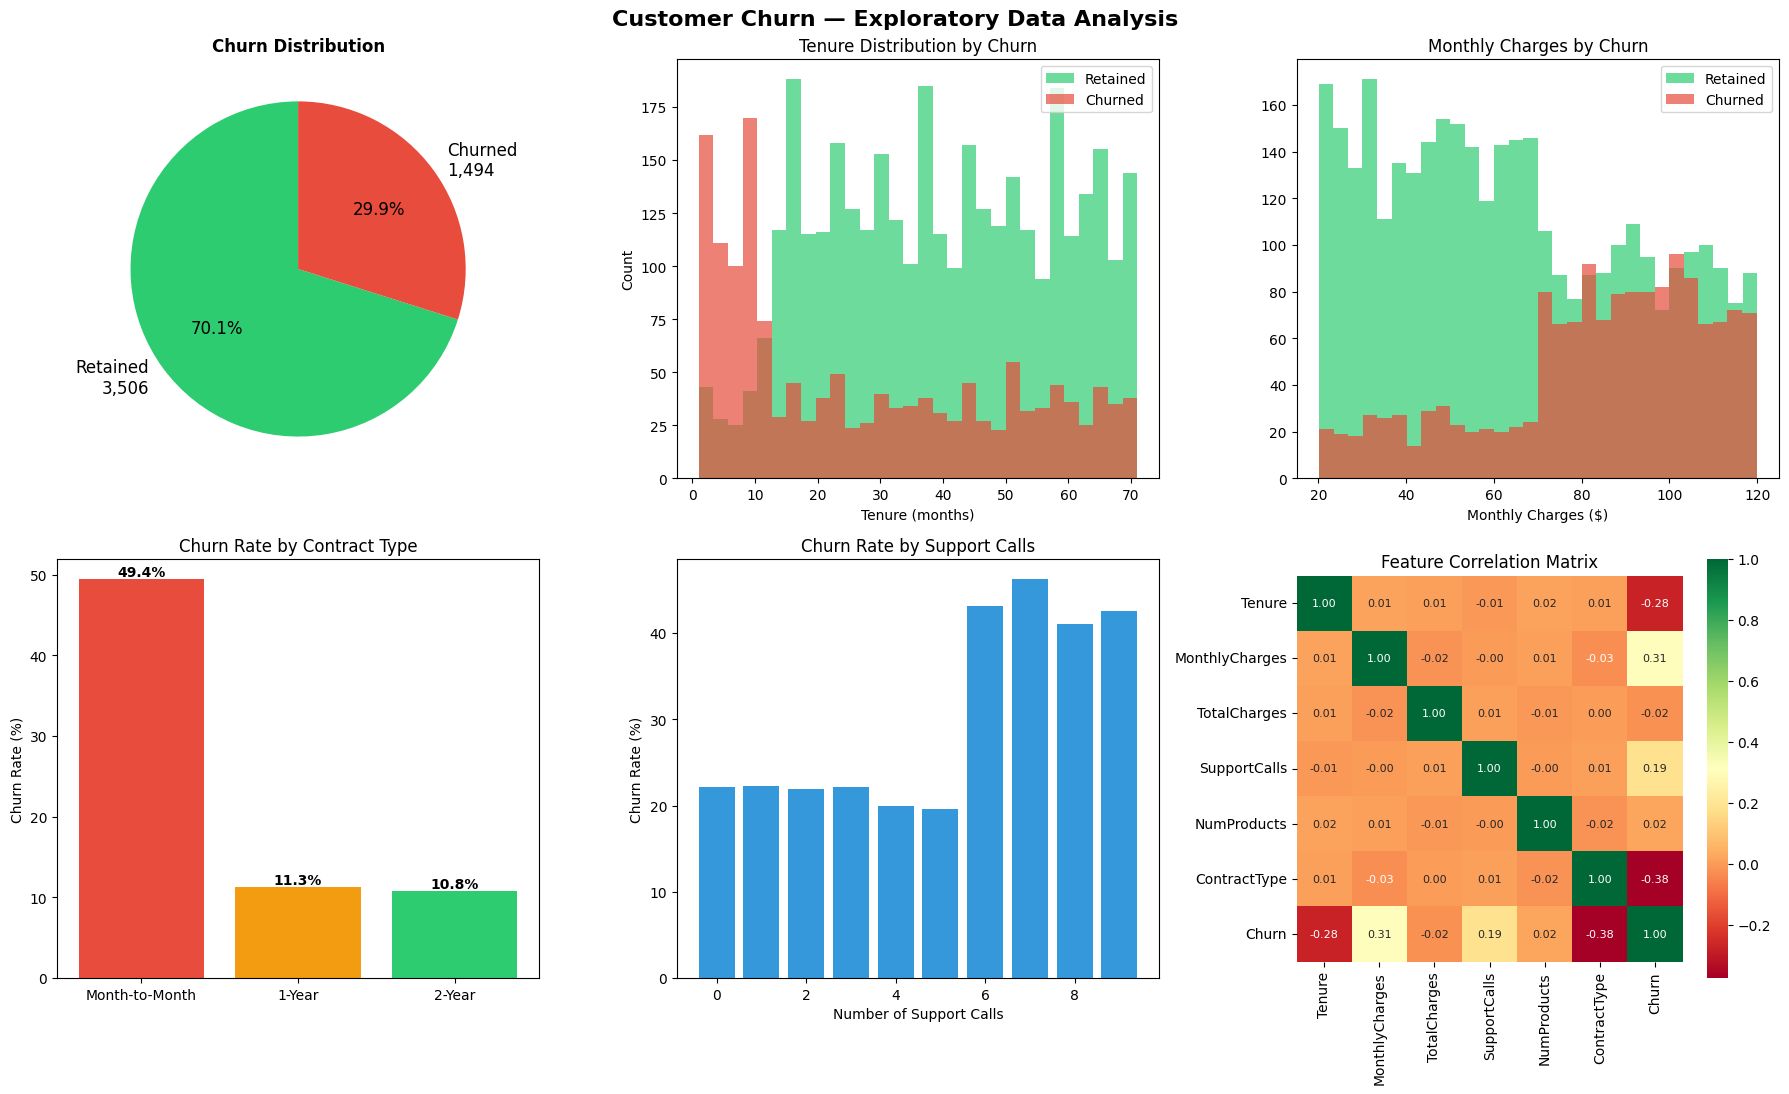

✅ EDA plots saved as churn_eda.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = hdf.collect()
churned   = df_plot[df_plot['Churn'] == 1]
retained  = df_plot[df_plot['Churn'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Customer Churn — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Churn distribution pie
labels  = [f'Retained\n{len(retained):,}', f'Churned\n{len(churned):,}']
sizes   = [len(retained), len(churned)]
colors  = ['#2ecc71', '#e74c3c']
axes[0,0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 12})
axes[0,0].set_title('Churn Distribution', fontweight='bold')

# 2. Tenure by churn
axes[0,1].hist(retained['Tenure'], bins=30, alpha=0.7, color='#2ecc71', label='Retained')
axes[0,1].hist(churned['Tenure'],  bins=30, alpha=0.7, color='#e74c3c', label='Churned')
axes[0,1].set_title('Tenure Distribution by Churn')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# 3. Monthly charges by churn
axes[0,2].hist(retained['MonthlyCharges'], bins=30, alpha=0.7, color='#2ecc71', label='Retained')
axes[0,2].hist(churned['MonthlyCharges'],  bins=30, alpha=0.7, color='#e74c3c', label='Churned')
axes[0,2].set_title('Monthly Charges by Churn')
axes[0,2].set_xlabel('Monthly Charges ($)')
axes[0,2].legend()

# 4. Contract type vs churn
contract_churn = df_plot.groupby('ContractType')['Churn'].mean() * 100
contract_names = ['Month-to-Month', '1-Year', '2-Year']
bars = axes[1,0].bar(contract_names, contract_churn.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[1,0].set_title('Churn Rate by Contract Type')
axes[1,0].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, contract_churn.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold')

# 5. Support calls vs churn
support_churn = df_plot.groupby('SupportCalls')['Churn'].mean() * 100
axes[1,1].bar(support_churn.index, support_churn.values, color='#3498db')
axes[1,1].set_title('Churn Rate by Support Calls')
axes[1,1].set_xlabel('Number of Support Calls')
axes[1,1].set_ylabel('Churn Rate (%)')

# 6. Correlation heatmap
features_corr = ['Tenure','MonthlyCharges','TotalCharges','SupportCalls',
                  'NumProducts','ContractType','Churn']
corr = df_plot[features_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1,2], square=True, annot_kws={'size': 8})
axes[1,2].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved as churn_eda.png')

## 🔧 Step 5: Feature Engineering & Train/Test Split

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

FEATURES = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'NumProducts',
            'SupportCalls', 'ContractType', 'PaymentMethod',
            'PaperlessBilling', 'InternetService', 'StreamingTV',
            'TechSupport', 'SeniorCitizen', 'Partner', 'Dependents']
TARGET = 'Churn'

X = df_plot[FEATURES]
y = df_plot[TARGET]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'   Churn rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')
print(f'   Features: {len(FEATURES)}')

✅ Train: 4,000 rows | Test: 1,000 rows
   Churn rate — Train: 29.9% | Test: 29.9%
   Features: 14


## 🤖 Step 6: Train Classification Models

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                        max_depth=4, random_state=42)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    start = time.time()

    # Use scaled data for Logistic Regression
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    elapsed   = time.time() - start
    y_pred    = model.predict(X_te)
    y_proba   = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1'        : f1_score(y_test, y_pred),
        'ROC_AUC'   : roc_auc_score(y_test, y_proba),
        'Time'      : elapsed
    }
    print(f'✅ F1={results[name]["F1"]:.4f} | AUC={results[name]["ROC_AUC"]:.4f} | Time={elapsed:.1f}s')

print('\n✅ All models trained!')

Training Logistic Regression... ✅ F1=0.6852 | AUC=0.8805 | Time=0.5s
Training Random Forest... ✅ F1=0.8814 | AUC=0.9814 | Time=0.6s
Training Gradient Boosting... ✅ F1=0.8863 | AUC=0.9826 | Time=2.9s

✅ All models trained!


## 📈 Step 7: Model Evaluation & Visualization

In [10]:
# Performance table
comparison = pd.DataFrame([
    {
        'Model'    : name,
        'Accuracy' : f"{r['Accuracy']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'Recall'   : f"{r['Recall']:.4f}",
        'F1 Score' : f"{r['F1']:.4f}",
        'ROC-AUC'  : f"{r['ROC_AUC']:.4f}",
        'Train Time': f"{r['Time']:.1f}s"
    }
    for name, r in results.items()
])

print('=== Model Performance Comparison ===')
print(comparison.to_string(index=False))

best_model_name = max(results, key=lambda x: results[x]['ROC_AUC'])
print(f'\n🏆 Best Model: {best_model_name} (AUC={results[best_model_name]["ROC_AUC"]:.4f})')

=== Model Performance Comparison ===
              Model Accuracy Precision Recall F1 Score ROC-AUC Train Time
Logistic Regression   0.8190    0.7138 0.6589   0.6852  0.8805       0.5s
      Random Forest   0.9300    0.8935 0.8696   0.8814  0.9814       0.6s
  Gradient Boosting   0.9320    0.8863 0.8863   0.8863  0.9826       2.9s

🏆 Best Model: Gradient Boosting (AUC=0.9826)


/tmp/ipykernel_22051/3815050949.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(model_names, rotation=10)


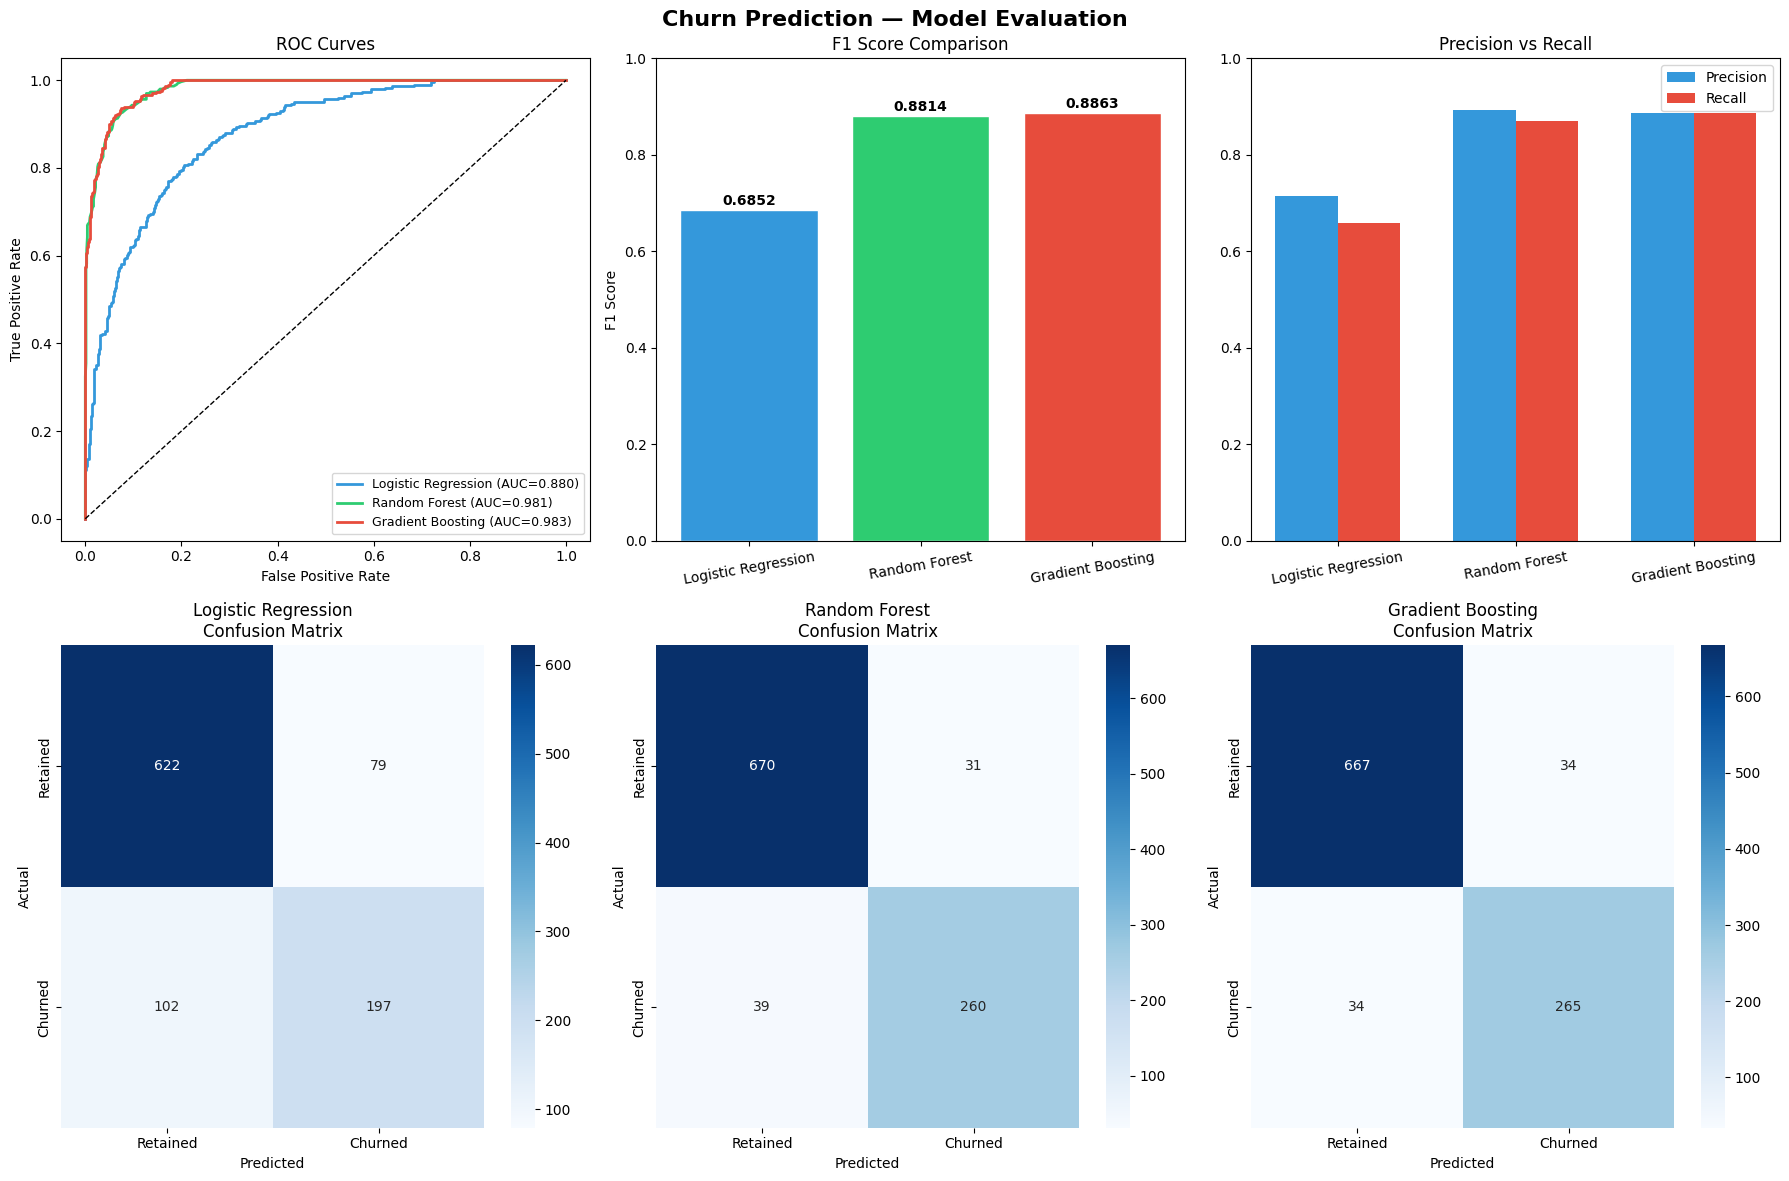

✅ Evaluation plots saved as churn_evaluation.png


In [11]:
model_names  = list(results.keys())
model_colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Churn Prediction — Model Evaluation', fontsize=16, fontweight='bold')

# 1. ROC Curves
for name, color in zip(model_names, model_colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    auc = results[name]['ROC_AUC']
    axes[0,0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
axes[0,0].plot([0,1],[0,1],'k--', lw=1)
axes[0,0].set_title('ROC Curves')
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].legend(fontsize=9)

# 2. F1 Score comparison
f1_vals = [results[m]['F1'] for m in model_names]
bars = axes[0,1].bar(model_names, f1_vals, color=model_colors, edgecolor='white')
axes[0,1].set_title('F1 Score Comparison')
axes[0,1].set_ylabel('F1 Score')
axes[0,1].set_ylim(0, 1)
for bar, val in zip(bars, f1_vals):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.4f}', ha='center', fontweight='bold')
axes[0,1].set_xticklabels(model_names, rotation=10)

# 3. Precision vs Recall
x_pos = np.arange(len(model_names))
width = 0.35
prec_vals   = [results[m]['Precision'] for m in model_names]
recall_vals = [results[m]['Recall']    for m in model_names]
axes[0,2].bar(x_pos - width/2, prec_vals,   width, label='Precision', color='#3498db')
axes[0,2].bar(x_pos + width/2, recall_vals, width, label='Recall',    color='#e74c3c')
axes[0,2].set_title('Precision vs Recall')
axes[0,2].set_xticks(x_pos)
axes[0,2].set_xticklabels(model_names, rotation=10)
axes[0,2].set_ylim(0, 1)
axes[0,2].legend()

# 4, 5, 6. Confusion matrices
for idx, (name, color) in enumerate(zip(model_names, model_colors)):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, idx],
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'])
    axes[1,idx].set_title(f'{name}\nConfusion Matrix')
    axes[1,idx].set_xlabel('Predicted')
    axes[1,idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('churn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Evaluation plots saved as churn_evaluation.png')

## 🔍 Step 8: Feature Importance & Churn Drivers

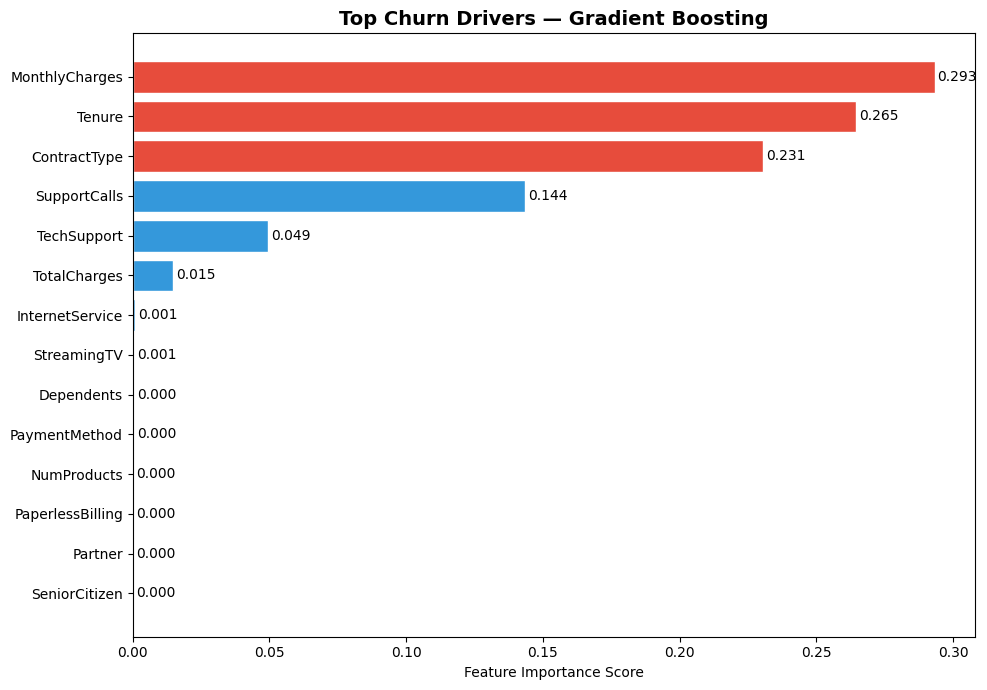


=== Top 5 Churn Drivers ===
       Feature  Importance
MonthlyCharges    0.293336
        Tenure    0.264565
  ContractType    0.230586
  SupportCalls    0.143572
   TechSupport    0.049458


In [12]:
best_model = results[best_model_name]['model']

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature'   : FEATURES,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_imp = ['#e74c3c' if i >= len(FEATURES)-3 else '#3498db'
                  for i in range(len(importance_df))]
    bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
                   color=colors_imp, edgecolor='white')
    ax.set_xlabel('Feature Importance Score')
    ax.set_title(f'Top Churn Drivers — {best_model_name}',
                 fontsize=14, fontweight='bold')
    for bar, val in zip(bars, importance_df['Importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('churn_drivers.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n=== Top 5 Churn Drivers ===')
    print(importance_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

## 🚨 Step 9: Identify Top Churn Risk Customers

In [13]:
# Get churn probabilities for ALL customers
best = results[best_model_name]
X_all = df_plot[FEATURES]

if best_model_name == 'Logistic Regression':
    X_all_scaled = scaler.transform(X_all)
    churn_proba  = best['model'].predict_proba(X_all_scaled)[:, 1]
else:
    churn_proba  = best['model'].predict_proba(X_all)[:, 1]

# Build risk table
risk_df = df_plot[['CustomerID', 'Tenure', 'MonthlyCharges',
                    'ContractType', 'SupportCalls', 'Churn']].copy()
risk_df['ChurnProbability'] = np.round(churn_proba, 4)
risk_df['RiskLevel'] = pd.cut(
    risk_df['ChurnProbability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
risk_df['ContractType'] = risk_df['ContractType'].map(
    {0: 'Month-to-Month', 1: '1-Year', 2: '2-Year'}
)

print('=== Risk Level Distribution ===')
print(risk_df['RiskLevel'].value_counts().to_string())
print('\n=== Top 10 Highest Churn Risk Customers ===')
print(risk_df.sort_values('ChurnProbability', ascending=False).head(10).to_string(index=False))

=== Risk Level Distribution ===
RiskLevel
Low Risk       3313
High Risk      1362
Medium Risk     325

=== Top 10 Highest Churn Risk Customers ===
CustomerID  Tenure  MonthlyCharges ContractType  SupportCalls  Churn  ChurnProbability RiskLevel
CUST_01809       8          103.55       2-Year             7      1            0.9989 High Risk
CUST_01216      11           82.12       2-Year             9      1            0.9989 High Risk
CUST_03171       9          112.20       1-Year             7      1            0.9987 High Risk
CUST_02789       5           82.84       1-Year             8      1            0.9985 High Risk
CUST_04091       8           76.30       2-Year             8      1            0.9985 High Risk
CUST_04064      10           82.19       2-Year             7      1            0.9985 High Risk
CUST_01880       6          102.52       1-Year             9      1            0.9984 High Risk
CUST_01426      11           79.41       1-Year             7      1         

## 💾 Step 10: Save Results Back to SAP HANA

In [14]:
# Save full risk table to HANA
hdf_risk = create_dataframe_from_pandas(
    connection_context=conn,
    pandas_df=risk_df,
    table_name='churn_predictions',
    schema=HANA_SCHEMA,
    force=True
)
print(f'✅ Churn predictions saved! Rows: {hdf_risk.count():,}')

# Query high risk customers from HANA
high_risk = conn.sql("""
    SELECT "CustomerID", "Tenure", "MonthlyCharges",
           "ContractType", "SupportCalls", "ChurnProbability", "RiskLevel"
    FROM "ML_DEMO"."churn_predictions"
    WHERE "RiskLevel" = 'High Risk'
    ORDER BY "ChurnProbability" DESC
    LIMIT 10
""")
print('\n=== Top High Risk Customers (from HANA) ===')
print(high_risk.collect().to_string(index=False))

100%|██████████| 1/1 [00:00<00:00,  3.03it/s]


✅ Churn predictions saved! Rows: 5,000

=== Top High Risk Customers (from HANA) ===
CustomerID  Tenure  MonthlyCharges ContractType  SupportCalls  ChurnProbability RiskLevel
CUST_01809       8          103.55       2-Year             7            0.9989 High Risk
CUST_01216      11           82.12       2-Year             9            0.9989 High Risk
CUST_03171       9          112.20       1-Year             7            0.9987 High Risk
CUST_04064      10           82.19       2-Year             7            0.9985 High Risk
CUST_04091       8           76.30       2-Year             8            0.9985 High Risk
CUST_02789       5           82.84       1-Year             8            0.9985 High Risk
CUST_01880       6          102.52       1-Year             9            0.9984 High Risk
CUST_01426      11           79.41       1-Year             7            0.9982 High Risk
CUST_02096       2           79.36       2-Year             7            0.9980 High Risk
CUST_03786      

## 📋 Step 11: Final Summary

In [15]:
high_risk_count = len(risk_df[risk_df['RiskLevel'] == 'High Risk'])
mid_risk_count  = len(risk_df[risk_df['RiskLevel'] == 'Medium Risk'])
low_risk_count  = len(risk_df[risk_df['RiskLevel'] == 'Low Risk'])

print('=' * 57)
print('   📉 CUSTOMER CHURN PREDICTION — PROJECT SUMMARY')
print('=' * 57)
print(f'   Database     : SAP HANA Cloud')
print(f'   Schema       : {HANA_SCHEMA}')
print(f'   Customers    : {len(df):,}')
print(f'   Churn Rate   : {df["Churn"].mean():.1%}')
print(f'   Train / Test : {len(X_train):,} / {len(X_test):,}')
print()
print('   Model Results:')
for name, r in results.items():
    marker = '🏆' if name == best_model_name else '  '
    print(f'   {marker} {name:<25} F1={r["F1"]:.4f}  AUC={r["ROC_AUC"]:.4f}')
print()
print(f'   Best Model   : {best_model_name}')
print(f'   Best AUC     : {results[best_model_name]["ROC_AUC"]:.4f}')
print(f'   Best F1      : {results[best_model_name]["F1"]:.4f}')
print()
print('   Customer Risk Segments:')
print(f'   🔴 High Risk    : {high_risk_count:,} customers')
print(f'   🟡 Medium Risk  : {mid_risk_count:,} customers')
print(f'   🟢 Low Risk     : {low_risk_count:,} customers')
print()
print('   Outputs saved to HANA:')
print('   ✅ ML_DEMO.telco_customers     (raw data)')
print('   ✅ ML_DEMO.churn_predictions   (risk scores)')
print('=' * 57)

conn.close()
print('\n✅ Connection closed. Project complete!')

   📉 CUSTOMER CHURN PREDICTION — PROJECT SUMMARY
   Database     : SAP HANA Cloud
   Schema       : ML_DEMO
   Customers    : 5,000
   Churn Rate   : 29.9%
   Train / Test : 4,000 / 1,000

   Model Results:
      Logistic Regression       F1=0.6852  AUC=0.8805
      Random Forest             F1=0.8814  AUC=0.9814
   🏆 Gradient Boosting         F1=0.8863  AUC=0.9826

   Best Model   : Gradient Boosting
   Best AUC     : 0.9826
   Best F1      : 0.8863

   Customer Risk Segments:
   🔴 High Risk    : 1,362 customers
   🟡 Medium Risk  : 325 customers
   🟢 Low Risk     : 3,313 customers

   Outputs saved to HANA:
   ✅ ML_DEMO.telco_customers     (raw data)
   ✅ ML_DEMO.churn_predictions   (risk scores)

✅ Connection closed. Project complete!
